# Run analysis: layer norm, activation, and observation normalization

This notebook loads all runs from the `runs/` directory, filters to those that appear to have finished, and then analyzes how **activation function**, **layer normalization**, and **observation normalization** relate to performance.


In [1]:
import json
import os
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

RUNS_DIR = Path("runs")
RUNS_DIR.resolve()


PosixPath('/homes/cdt24/jarek/envelope-bench/runs')

## Load all runs

We look for subdirectories of `runs/` that contain both a `config.json` and a `metrics.h5`. For each run we extract:

- basic configuration (environment name, seed, total timesteps, activation, layer norm, observation normalization)
- training metrics from `metrics.h5` (steps and mean return)

A run is considered **finished** if the last logged `steps` value is greater than or equal to `total_timesteps` from the config.


In [2]:
def iter_run_dirs(root: Path = RUNS_DIR):
    """Yield (env_name, run_dir) pairs for all runs that have config and metrics files."""
    if not root.exists():
        raise FileNotFoundError(f"Runs directory not found: {root}")

    for env_dir in sorted(root.iterdir()):
        if not env_dir.is_dir():
            continue
        for run_dir in sorted(env_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            cfg_path = run_dir / "config.json"
            metrics_path = run_dir / "metrics.h5"
            if cfg_path.exists() and metrics_path.exists():
                yield env_dir.name, run_dir


records = []
for env_name, run_dir in iter_run_dirs():
    cfg_path = run_dir / "config.json"
    metrics_path = run_dir / "metrics.h5"

    with cfg_path.open("r") as f:
        cfg = json.load(f)

    try:
        with h5py.File(metrics_path, "r") as f:
            steps = np.asarray(f["steps"], dtype=float)
            mean_return = np.asarray(f["mean_return"], dtype=float)
    except:
        print(f"Failed on run {metrics_path}, skipping...")
        continue

    if steps.size == 0:
        # Skip empty runs
        continue

    total_timesteps = float(cfg.get("total_timesteps", steps[-1]))
    last_step = float(steps[-1])
    finished = last_step >= total_timesteps

    record = {
        "env_name": cfg.get("env_name", env_name),
        "run_dir": str(run_dir),
        "seed": cfg.get("seed"),
        "activation": cfg.get("activation"),
        "layer_norm": cfg.get("layer_norm"),
        "normalize_observations": cfg.get("normalize_observations"),
        "total_timesteps": total_timesteps,
        "last_step": last_step,
        "finished": finished,
        "final_return": float(mean_return[-1]),
    }
    records.append(record)

df = pd.DataFrame.from_records(records)
print(f"Loaded {len(df)} runs from {RUNS_DIR}")
df.head()


Failed on run runs/brax::hopper/20260210_233201/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_023940/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_024021/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_151716/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_151735/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_151749/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_151945/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_153342/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_153404/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_153434/metrics.h5, skipping...
Failed on run runs/brax::hopper/20260211_153611/metrics.h5, skipping...
Failed on run runs/craftax::Craftax-Classic-Symbolic-v1/20260211_024124/metrics.h5, skipping...
Failed on run runs/craftax::Craftax-Classic-Symbolic-v1/20260211_024139/metrics.h5, skipping...
Failed on run ru

,env_name,run_dir,seed,activation,layer_norm,normalize_observations,total_timesteps,last_step,finished,final_return
0,brax::hopper,runs/brax::hopper/20260210_232716,0,relu,False,False,1000000.0,166000.0,False,NaN
1,brax::hopper,runs/brax::hopper/20260210_233108,0,relu,False,False,1000000.0,1000.0,False,NaN
2,brax::hopper,runs/brax::hopper/20260210_233413,0,relu,False,False,100000000.0,100000000.0,True,NaN
3,brax::hopper,runs/brax::hopper/20260210_233841,0,relu,True,False,100000000.0,100000000.0,True,NaN
4,brax::hopper,runs/brax::hopper/20260211_001602,0,relu,False,False,100000000.0,4300000.0,False,51.083365


## Filter to finished runs

We now keep only runs where the last logged `steps` value reaches (or exceeds) the target `total_timesteps`.


In [3]:
finished_df = df[df["finished"]].copy()
print(f"Finished runs: {len(finished_df)} / {len(df)}")
finished_df["env_name"].value_counts()


Finished runs: 241 / 255


env_name
gymnax::Breakout-MinAtar                43
gymnax::CartPole-v1                     39
brax::hopper                            32
craftax::Craftax-Classic-Symbolic-v1    32
jumanji::Snake-v1                       32
mujoco_playground::CartpoleBalance      30
navix::Navix-Empty-5x5-v0               30
craftax::Craftax-Symbolic-v1             3
Name: count, dtype: int64

## Analyze hyperparameter importance

We’ll use `final_return` (last value of `mean_return` over training) as a simple performance summary and look at how it varies with:

- activation function
- layer normalization (on/off)
- observation normalization (on/off)


In [4]:
# Activation function
activation_summary = (
    finished_df
    .groupby("activation")["final_return"]
    .describe()
    .sort_values("mean", ascending=False)
)
activation_summary


,count,mean,std,min,25%,50%,75%,max
activation,,,,,,,,
swish,57.0,528.004274,835.217608,0.0,15.672093,65.786665,828.884094,3451.190430
mish,42.0,506.190692,841.957274,0.0,16.477270,75.569968,619.874979,3625.362488
relu,71.0,467.840077,790.073665,0.0,14.801807,64.613666,500.000015,3691.522522
tanh,59.0,413.030997,550.071884,0.0,14.780718,53.409672,568.942667,2278.457001


In [5]:
# Layer normalization on/off
layer_norm_summary = (
    finished_df
    .groupby("layer_norm")["final_return"]
    .describe()
    .sort_values("mean", ascending=False)
)
layer_norm_summary


,count,mean,std,min,25%,50%,75%,max
layer_norm,,,,,,,,
True,58.0,570.659438,956.535586,0.5,15.479448,68.296169,500.000031,3451.190430
False,58.0,478.230263,865.673082,0.0,10.607059,27.192409,500.000000,3691.522522


In [6]:
# Observation normalization on/off
obs_norm_summary = (
    finished_df
    .groupby("normalize_observations")["final_return"]
    .describe()
    .sort_values("mean", ascending=False)
)
obs_norm_summary


,count,mean,std,min,25%,50%,75%,max
normalize_observations,,,,,,,,
True,169.0,480.556243,752.603483,0.0,16.028625,71.597411,659.833305,3691.522522
False,70.0,397.076837,726.421301,0.0,8.557306,15.543663,500.000000,3451.190430


In [7]:
# Joint analysis of all three hyperparameters
joint_summary = (
    finished_df
    .groupby(["activation", "layer_norm", "normalize_observations"])["final_return"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)
joint_summary


count        mean          std  \
activation layer_norm normalize_observations                                   
relu       True       True                        7  727.169791  1243.843655   
mish       True       True                        7  707.105443  1238.374042   
swish      True       False                       7  698.239513  1257.374915   
                      True                        7  658.625134  1135.149989   
relu       False      True                        7  630.238214  1361.412519   
mish       False      True                        7  613.771483  1340.051924   
swish      False      False                       7  534.023725   829.413706   
                      True                        7  523.093303  1085.049090   
tanh       False      False                       9  475.730457   755.261699   
           True       False                       8  467.833440   607.943368   
                      True                        7  460.357975   630.291694   
relu       True       False                      15  439.672991   869.454445   
tanh       False      True                        7  409.335905   545.931741   
relu       False      False                      14  320.181624   444.430941   

                                               min          max  
activation layer_norm normalize_observations                     
relu       True       True                    1.00  3425.859253  
mish       True       True                    1.00  3422.495911  
swish      True       False                   0.50  3451.190430  
                      True                    1.00  3125.768219  
relu       False      True                    0.00  3691.522522  
mish       False      True                    0.00  3625.362488  
swish      False      False                   0.00  2208.906464  
                      True                    0.00  2949.930298  
tanh       False      False                   0.00  2278.457001  
           True       False                   0.75  1690.834167  
                      True                    0.50  1624.927490  
relu       True       False                   0.75  3388.436523  
tanh       False      True                    1.00  1316.110428  
relu       False      False                   0.00  1422.999504

## Simple visualizations

Bar plots of mean `final_return` by activation and boolean hyperparameters.


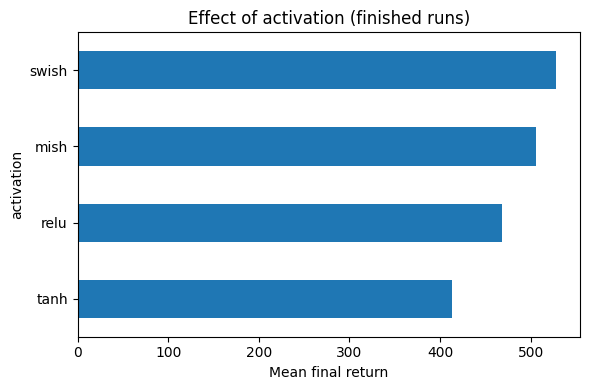

In [8]:
plt.figure(figsize=(6, 4))
(
    finished_df
    .groupby("activation")["final_return"]
    .mean()
    .sort_values()
    .plot(kind="barh")
)
plt.xlabel("Mean final return")
plt.title("Effect of activation (finished runs)")
plt.tight_layout()
plt.show()


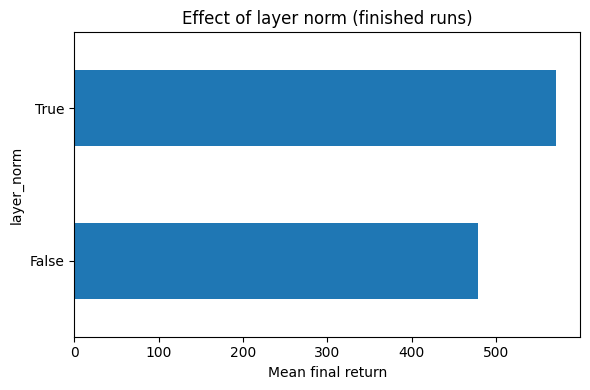

In [9]:
plt.figure(figsize=(6, 4))
(
    finished_df
    .groupby("layer_norm")["final_return"]
    .mean()
    .sort_values()
    .plot(kind="barh")
)
plt.xlabel("Mean final return")
plt.title("Effect of layer norm (finished runs)")
plt.tight_layout()
plt.show()


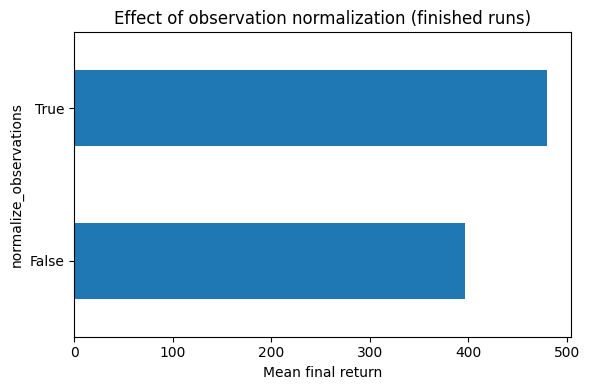

In [18]:
plt.figure(figsize=(6, 4))
(
    finished_df
    .groupby("normalize_observations")["final_return"]
    .mean()
    .sort_values()
    .plot(kind="barh")
)
plt.xlabel("Mean final return")
plt.title("Effect of observation normalization (finished runs)")
plt.tight_layout()
plt.show()


## Per-environment comparison of hyperparameters

The plot below shows, for each environment, the mean `final_return` for every combination of:

- activation function
- layer normalization on/off
- observation normalization on/off

Each bar is one `(activation, layer_norm, normalize_observations)` configuration within that environment.

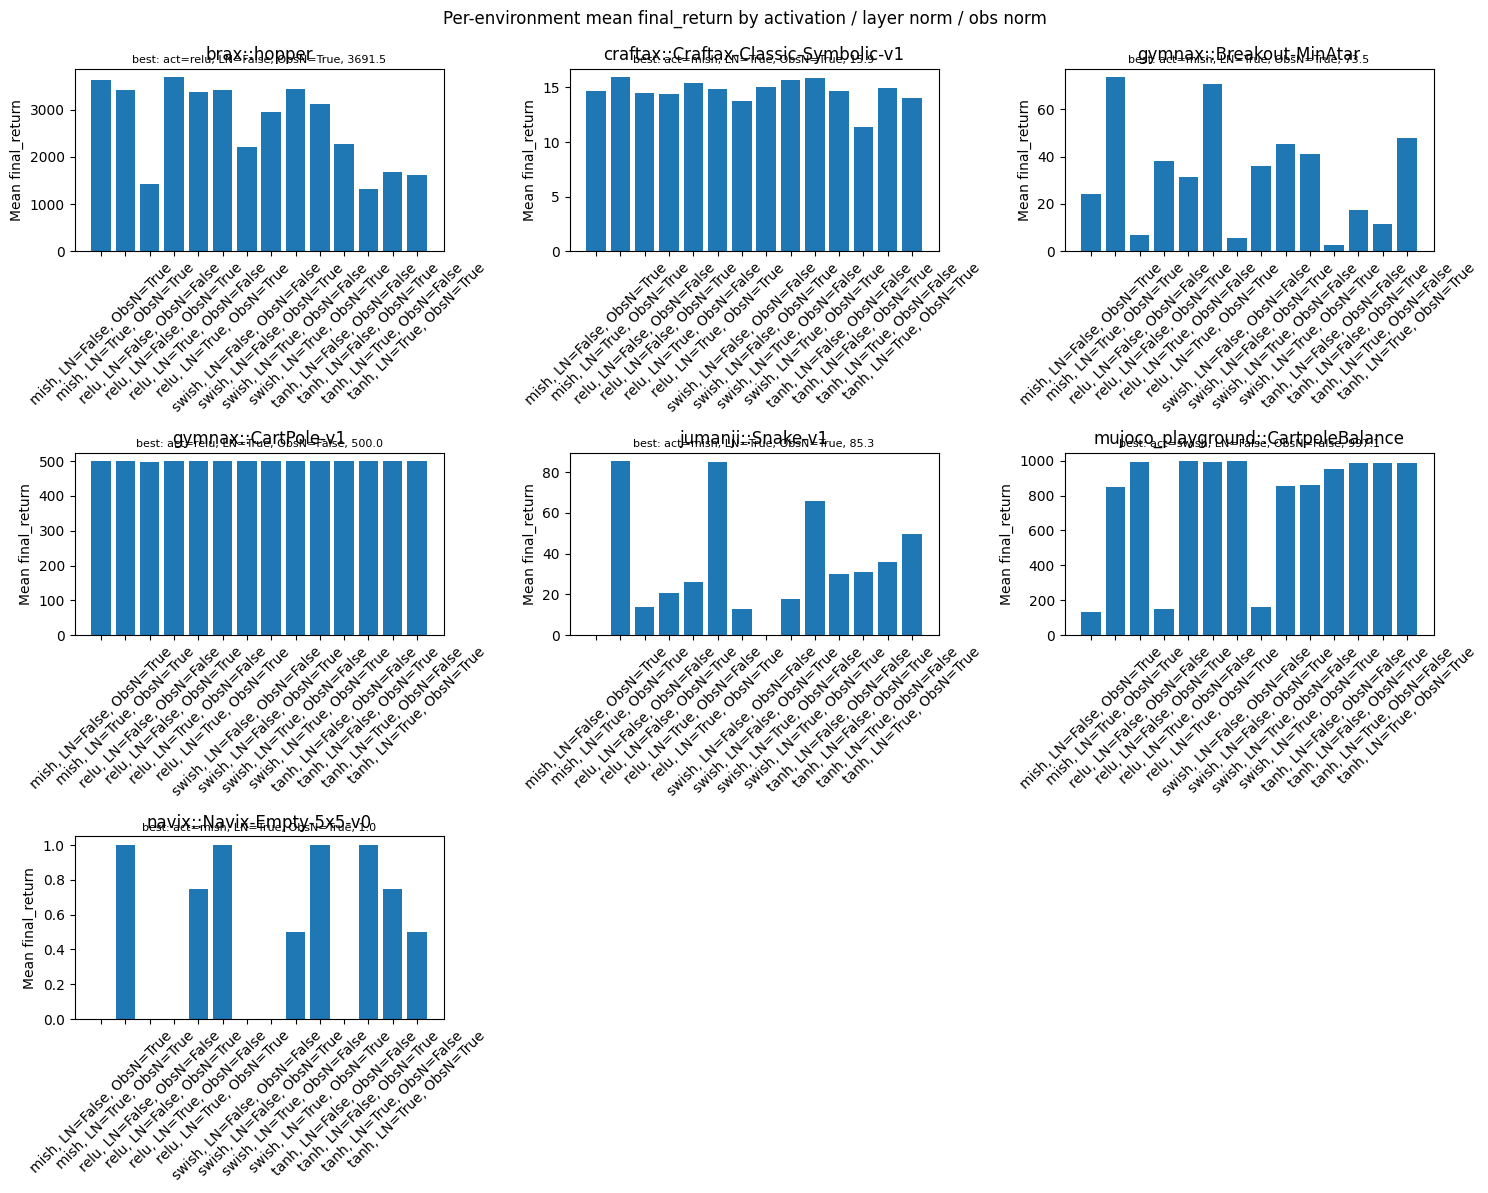

In [11]:
import math

# Aggregate mean final_return per env + hyperparameter combo
agg = (
    finished_df
    .groupby(["env_name", "activation", "layer_norm", "normalize_observations"])["final_return"]
    .mean()
    .reset_index()
)

envs = sorted(agg["env_name"].unique())
num_envs = len(envs)

if num_envs == 0:
    print("No finished runs to plot.")
else:
    ncols = 3
    nrows = math.ceil(num_envs / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for ax, env in zip(axes, envs):
        sub = agg[agg["env_name"] == env].copy()
        if sub.empty:
            ax.axis("off")
            continue

        # Build a compact label for each hyperparameter combination
        sub["label"] = sub.apply(
            lambda r: f"{r['activation']}, LN={bool(r['layer_norm'])}, ObsN={bool(r['normalize_observations'])}",
            axis=1,
        )

        ax.bar(sub["label"], sub["final_return"])

        # Add text summarizing the best combination for this env
        best_idx = sub["final_return"].idxmax()
        best_row = sub.loc[best_idx]
        best_text = (
            f"best: act={best_row['activation']}, "
            f"LN={bool(best_row['layer_norm'])}, "
            f"ObsN={bool(best_row['normalize_observations'])}, "
            f"{best_row['final_return']:.1f}"
        )
        ax.text(
            0.5,
            1.02,
            best_text,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=8,
        )

        ax.set_title(env)
        ax.set_ylabel("Mean final_return")
        # Rotate x tick labels for readability
        ax.tick_params(axis="x", labelrotation=45)

    # Turn off any unused axes
    for ax in axes[len(envs):]:
        ax.axis("off")

    plt.suptitle("Per-environment mean final_return by activation / layer norm / obs norm", y=0.99)
    plt.tight_layout()
    plt.show()


## Per-environment plots for individual hyperparameters

The following plots show, for each environment separately, how `final_return` depends on:

- activation function
- layer normalization (on/off)
- observation normalization (on/off)


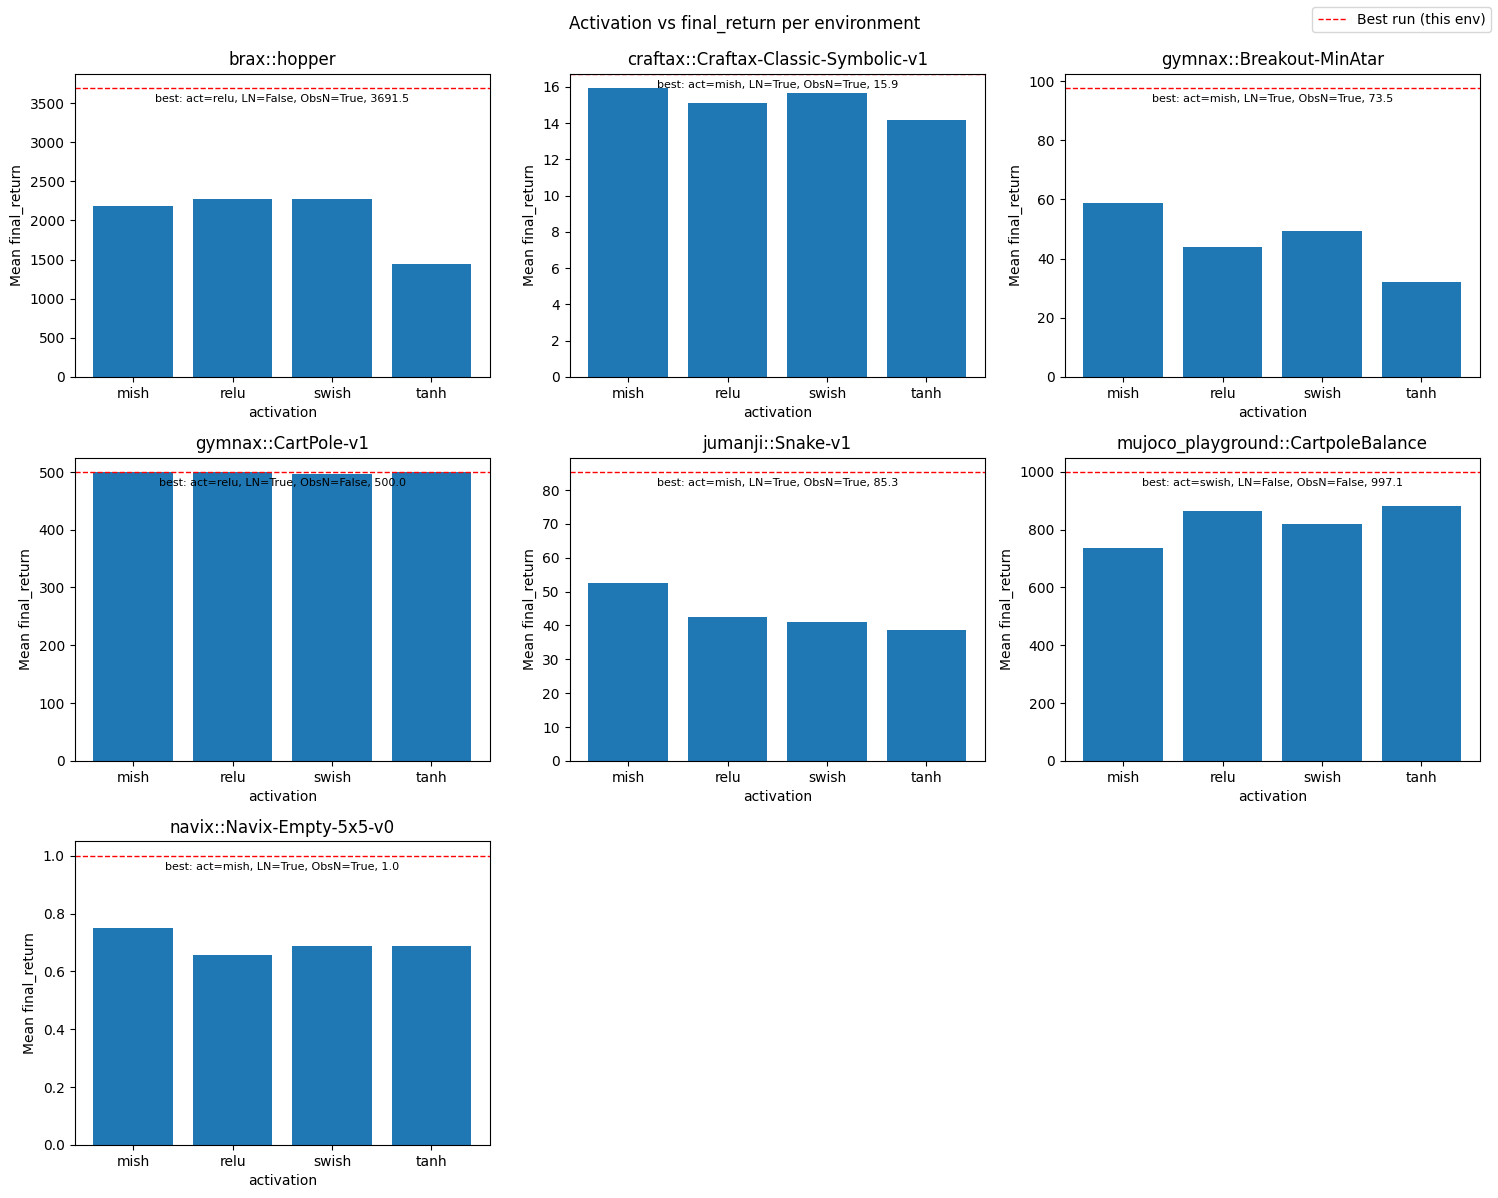

In [12]:
import math

# Helper to make a grid of subplots for per-env bar plots

def plot_per_env_bar(df, group_key: str, title_prefix: str):
    agg = (
        df
        .groupby(["env_name", group_key])["final_return"]
        .mean()
        .reset_index()
    )
    envs = sorted(agg["env_name"].unique())
    if not envs:
        print("No finished runs to plot.")
        return

    # Best run per environment (reference line)
    best_per_env = (
        df.groupby("env_name")["final_return"].max()
    )

    ncols = 3
    nrows = math.ceil(len(envs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for ax, env in zip(axes, envs):
        sub = agg[agg["env_name"] == env]
        if sub.empty:
            ax.axis("off")
            continue
        ax.bar(sub[group_key].astype(str), sub["final_return"])

        # Per-environment best final_return as reference line
        ref = best_per_env.get(env, None)
        if ref is not None and not np.isnan(ref):
            ax.axhline(ref, color="red", linestyle="--", linewidth=1.0)
            ylim = ax.get_ylim()
            y_text = ref - 0.02 * (ylim[1] - ylim[0])
        else:
            ylim = ax.get_ylim()
            y_text = ylim[1] - 0.02 * (ylim[1] - ylim[0])

        # Text annotation for the best full hyperparameter combo in this env
        env_df = df[df["env_name"] == env]
        if not env_df.empty:
            combo_stats = (
                env_df
                .groupby(["activation", "layer_norm", "normalize_observations"])["final_return"]
                .mean()
            )
            if len(combo_stats) == 0:
                continue
            best_activation, best_ln, best_obs = combo_stats.idxmax()
            best_val = combo_stats.max()
            best_text = (
                f"best: act={best_activation}, "
                f"LN={bool(best_ln)}, "
                f"ObsN={bool(best_obs)}, "
                f"{best_val:.1f}"
            )
            mid_x = (len(sub) - 1) / 2.0
            ax.text(
                mid_x,
                y_text,
                best_text,
                ha="center",
                va="top",
                fontsize=8,
            )

        ax.set_title(env)
        ax.set_ylabel("Mean final_return")
        ax.set_xlabel(group_key)

    for ax in axes[len(envs):]:
        ax.axis("off")

    # Add a single legend entry for the horizontal line
    fig.legend(["Best run (this env)"], loc="upper right")

    plt.suptitle(f"{title_prefix} per environment", y=0.99)
    plt.tight_layout()
    plt.show()

# Per-env activation effect
plot_per_env_bar(finished_df, "activation", "Activation vs final_return")


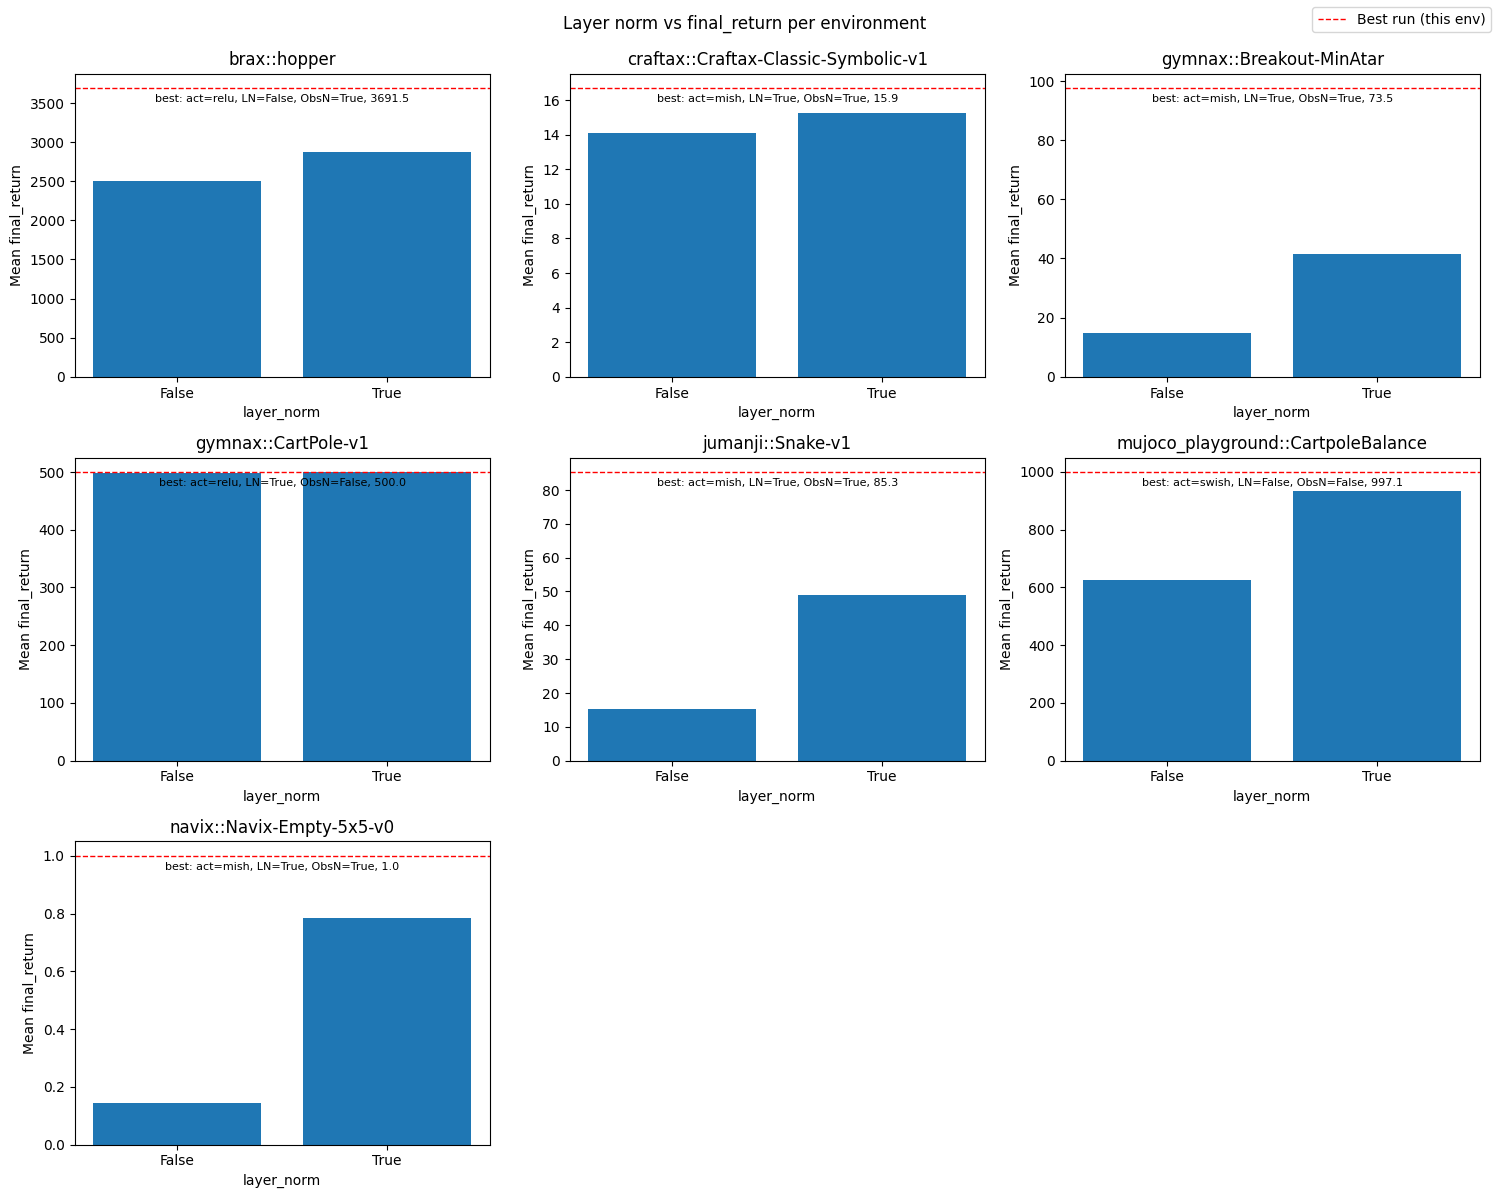

In [13]:
# Per-env layer_norm effect
plot_per_env_bar(finished_df, "layer_norm", "Layer norm vs final_return")


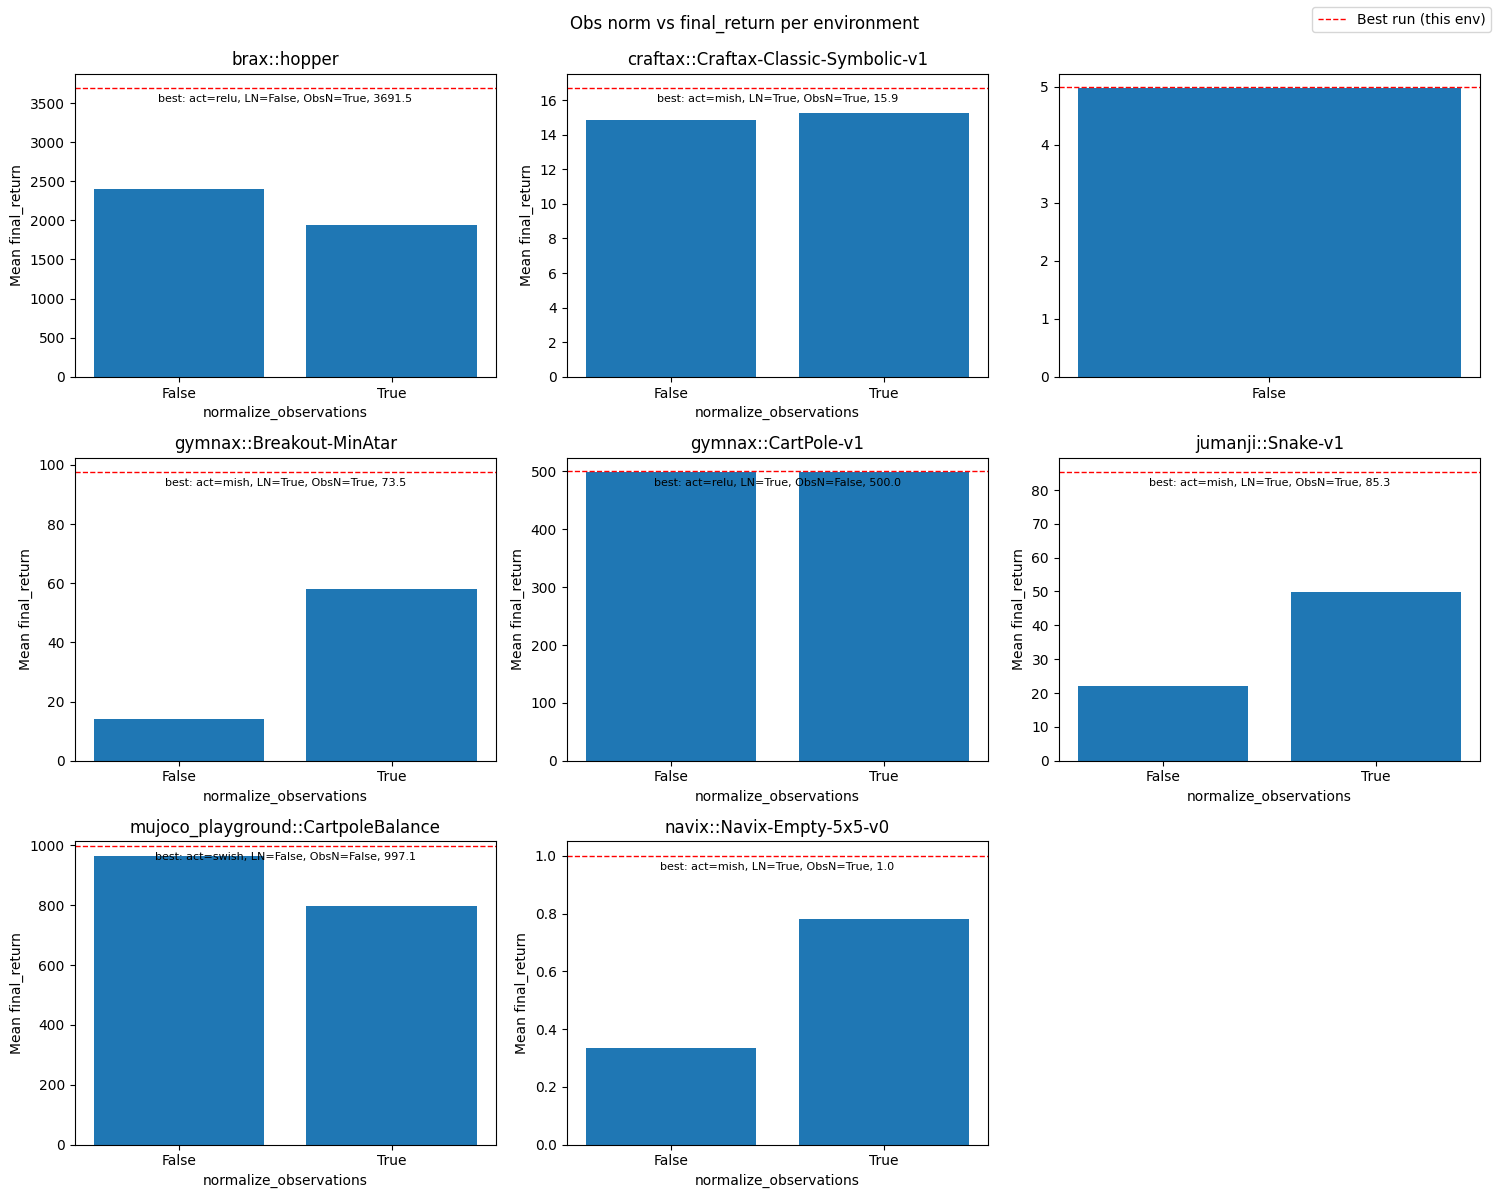

In [14]:
# Per-env observation normalization effect
plot_per_env_bar(finished_df, "normalize_observations", "Obs norm vs final_return")


## Swish: best on average, rarely best per environment

The plots below compare **swish** to the best activation per environment:

- For each env, we plot mean `final_return` for swish (when present) vs the best activation in that env.
- This makes it easy to see cases where swish has high overall mean performance but is not the per-env winner.

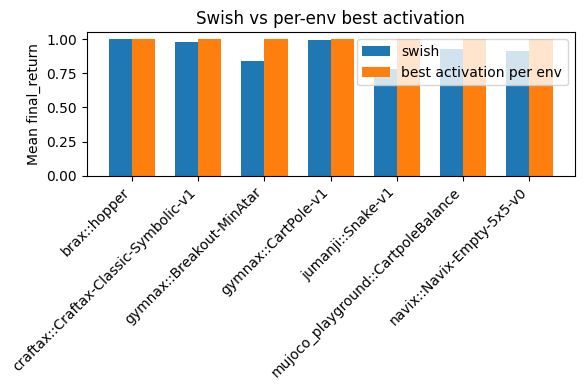

In [15]:
# Compare swish to per-env best activation

# Mean final_return per (env, activation)
act_env = (
    finished_df
    .groupby(["env_name", "activation"])["final_return"]
    .mean()
    .reset_index()
)

# Pivot to env x activation table
act_pivot = act_env.pivot(index="env_name", columns="activation", values="final_return")

# Determine best activation per env
best_act_per_env = act_pivot.idxmax(axis=1)
best_val_per_env = act_pivot.max(axis=1)

# Swish values where available
swish_vals = act_pivot.get("swish")

# Keep envs where swish exists
mask = swish_vals.notna()
plot_envs = act_pivot.index[mask]

if plot_envs.empty:
    print("No environments with swish runs to compare.")
else:
    x = np.arange(len(plot_envs))
    width = 0.35

    plt.figure(figsize=(max(6, len(plot_envs) * 0.8), 4))

    plt.bar(x - width/2, swish_vals[plot_envs] / best_val_per_env[plot_envs], width=width, label="swish")
    plt.bar(x + width/2, 1, width=width, label="best activation per env")

    plt.xticks(x, plot_envs, rotation=45, ha="right")
    plt.ylabel("Mean final_return")
    plt.title("Swish vs per-env best activation")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Activation paradox: globally best but rarely wins per environment

The plots below compare:

- **Global mean `final_return` by activation** across all finished runs.
- **Number of environments where each activation is the best** (highest mean `final_return` in that env).

This helps visualize cases like `swish` having the highest overall mean but almost never being the top choice within any single environment.

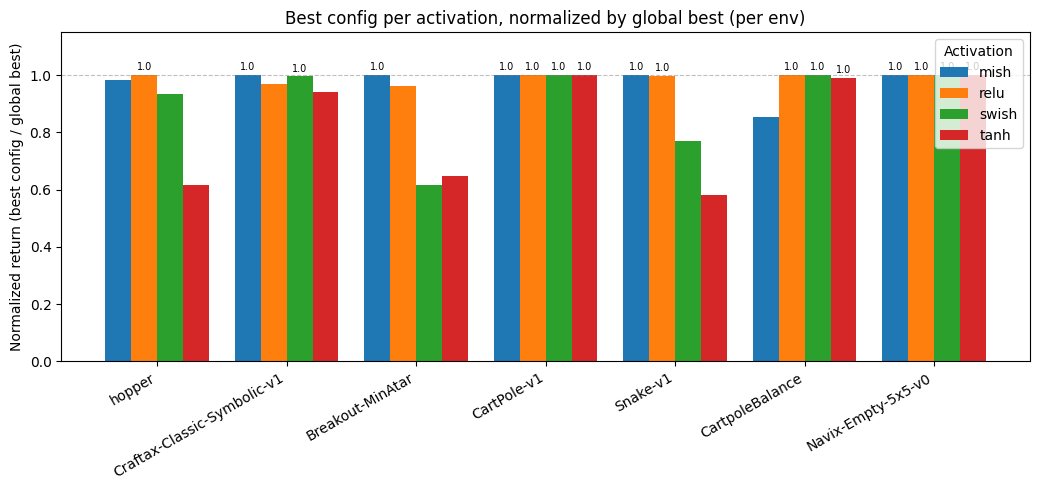

In [16]:
# For each (env, activation), take the best config (over LN/ObsNorm).
# Normalize by the global best config for that env.

best_per_act = (
    finished_df
    .groupby(["env_name", "activation", "layer_norm", "normalize_observations"])["final_return"]
    .mean()
    .groupby(level=["env_name", "activation"])
    .max()
    .reset_index(name="best_return")
)

global_best = (
    best_per_act
    .groupby("env_name")["best_return"]
    .max()
    .rename("global_best")
)

best_per_act = best_per_act.merge(global_best, on="env_name")
best_per_act["normalized"] = best_per_act["best_return"] / best_per_act["global_best"]

# Pivot for grouped bar chart
pivot = best_per_act.pivot(index="env_name", columns="activation", values="normalized").fillna(0)

# Shorten env names for readability
short_names = [n.split("::")[-1] for n in pivot.index]

activations = sorted(pivot.columns)
x = np.arange(len(pivot))
width = 0.8 / len(activations)

fig, ax = plt.subplots(figsize=(max(8, len(pivot) * 1.5), 5))
for i, act in enumerate(activations):
    offset = (i - len(activations) / 2 + 0.5) * width
    vals = pivot[act].values
    bars = ax.bar(x + offset, vals, width, label=act)
    # Label bars that reach 1.0
    for xi, v in zip(x + offset, vals):
        if v >= 0.99:
            ax.text(xi, v + 0.01, "1.0", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_ylabel("Normalized return (best config / global best)")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend(title="Activation", loc="upper right")
ax.set_title("Best config per activation, normalized by global best (per env)")
plt.tight_layout()
plt.show()
